# Script and Content Leakage Analysis

This notebook investigates what nuisance information remains encoded in the learned writer representations.

Previous experiments improved writer verification substantially, but cross-script verification remained weaker than within-script verification.

The current best SSL-initialized metric model also did not reduce the script-performance gap consistently.

This motivates a direct representation-level diagnostic.

## Research questions

The analysis asks:

1. How easily can handwriting script be predicted from frozen writer embeddings?
2. How easily can the same-text versus variable-text condition be predicted from frozen embeddings?
3. How does nuisance predictability change across representation-learning stages?
4. Does stronger writer verification coincide with stronger script or content leakage?

## Representations

Four frozen encoders will be compared:

- ImageNet-initialized ResNet-18
- Self-supervised MoCo handwriting encoder
- ImageNet-initialized dynamic supervised metric encoder
- SSL-initialized dynamic supervised metric encoder

All probes operate on the 512-dimensional L2-normalized backbone embeddings.

## Probe protocol

Probe training uses only development-training writers.

Probe evaluation uses writer-disjoint validation writers.

Writer identity is never supplied to the probe.

The primary script target is:

- Arabic
- English

The primary content-condition target is:

- variable text
- same text

Simple linear logistic-regression probes are used deliberately.

The purpose is not to build the strongest possible script or content classifier.

Instead, the probes test whether these attributes are already linearly recoverable from the frozen writer representation.

## Interpretation

High probe performance indicates that the corresponding nuisance attribute is explicitly accessible in the embedding space.

Low probe performance suggests weaker linear accessibility, but does not prove complete invariance.

Similarly, a smaller within-versus-cross-script verification gap does not by itself prove lower script leakage.

The leakage probes therefore complement, rather than replace, verification evaluation.

The official-test split will not be used to select probe hyperparameters or representation choices.

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader
from torchvision.models import ResNet18_Weights, resnet18

from handwriting_cross_script_research import QUWIDataset

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (
    PROJECT_ROOT / "pyproject.toml"
).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (
    PROJECT_ROOT
    / "pyproject.toml"
).exists()

IMAGE_DIR = (
    Path.home()
    / "Documents"
    / "Handwriting"
    / "QUWI"
    / "extracted"
    / "images"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "splits"
    / "quwi_writer_disjoint_split_seed42.csv"
)

SSL_CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "self_supervised_pretraining"
    / "resnet18_moco_ssl_best.pt"
)

DYNAMIC_CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "writer_aware_dynamic_sampling"
    / "resnet18_dynamic_sampling_best.pt"
)

HYBRID_CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "ssl_initialized_metric_learning"
    / "resnet18_ssl_initialized_dynamic_metric_best.pt"
)

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "script_content_leakage_analysis"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

split_df = pd.read_csv(
    SPLIT_PATH
)

development_df = (
    split_df[
        split_df[
            "experiment_split"
        ] == "development_train"
    ]
    .sort_values(
        [
            "writer",
            "page_id",
        ]
    )
    .reset_index(drop=True)
)

validation_df = (
    split_df[
        split_df[
            "experiment_split"
        ] == "validation"
    ]
    .sort_values(
        [
            "writer",
            "page_id",
        ]
    )
    .reset_index(drop=True)
)

development_dataset = QUWIDataset(
    metadata=development_df,
    image_dir=IMAGE_DIR,
)

validation_dataset = QUWIDataset(
    metadata=validation_df,
    image_dir=IMAGE_DIR,
)

development_loader = DataLoader(
    development_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print(
    "Development images:",
    len(
        development_df
    ),
)

print(
    "Development writers:",
    development_df[
        "writer"
    ].nunique(),
)

print(
    "Validation images:",
    len(
        validation_df
    ),
)

print(
    "Validation writers:",
    validation_df[
        "writer"
    ].nunique(),
)

print(
    "Development script counts:",
    development_df[
        "language"
    ].value_counts().to_dict(),
)

print(
    "Validation script counts:",
    validation_df[
        "language"
    ].value_counts().to_dict(),
)

print(
    "Development text-condition counts:",
    development_df[
        "same_text"
    ].value_counts().sort_index().to_dict(),
)

print(
    "Validation text-condition counts:",
    validation_df[
        "same_text"
    ].value_counts().sort_index().to_dict(),
)

print(
    "SSL checkpoint:",
    SSL_CHECKPOINT_PATH.exists(),
)

print(
    "Dynamic checkpoint:",
    DYNAMIC_CHECKPOINT_PATH.exists(),
)

print(
    "Hybrid checkpoint:",
    HYBRID_CHECKPOINT_PATH.exists(),
)

print(
    "Device:",
    DEVICE,
)

assert len(
    development_df
) == 904

assert len(
    validation_df
) == 224

assert development_df[
    "writer"
].nunique() == 226

assert validation_df[
    "writer"
].nunique() == 56

assert SSL_CHECKPOINT_PATH.exists()

assert DYNAMIC_CHECKPOINT_PATH.exists()

assert HYBRID_CHECKPOINT_PATH.exists()

Development images: 904
Development writers: 226
Validation images: 224
Validation writers: 56
Development script counts: {'Arabic': 452, 'English': 452}
Validation script counts: {'Arabic': 112, 'English': 112}
Development text-condition counts: {0: 452, 1: 452}
Validation text-condition counts: {0: 112, 1: 112}
SSL checkpoint: True
Dynamic checkpoint: True
Hybrid checkpoint: True
Device: cuda


In [3]:
IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406,
)

IMAGENET_STD = (
    0.229,
    0.224,
    0.225,
)


class FrozenEmbeddingModel(nn.Module):
    def __init__(
        self,
        weights=None,
    ):
        super().__init__()

        backbone = resnet18(
            weights=weights
        )

        backbone.fc = nn.Identity()

        self.feature_extractor = backbone

        self.register_buffer(
            "normalization_mean",
            torch.tensor(
                IMAGENET_MEAN
            ).view(
                1,
                3,
                1,
                1,
            ),
        )

        self.register_buffer(
            "normalization_std",
            torch.tensor(
                IMAGENET_STD
            ).view(
                1,
                3,
                1,
                1,
            ),
        )

        for parameter in self.parameters():
            parameter.requires_grad = False

    def forward(
        self,
        images,
    ):
        images = (
            images
            - self.normalization_mean
        ) / self.normalization_std

        embeddings = self.feature_extractor(
            images
        )

        return F.normalize(
            embeddings,
            p=2,
            dim=1,
        )


imagenet_model = FrozenEmbeddingModel(
    weights=ResNet18_Weights.DEFAULT
)

ssl_model = FrozenEmbeddingModel(
    weights=None
)

dynamic_model = FrozenEmbeddingModel(
    weights=None
)

hybrid_model = FrozenEmbeddingModel(
    weights=None
)

ssl_checkpoint = torch.load(
    SSL_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

dynamic_checkpoint = torch.load(
    DYNAMIC_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

hybrid_checkpoint = torch.load(
    HYBRID_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

ssl_prefix = "encoder_q.backbone."

ssl_backbone_state = {
    key[
        len(
            ssl_prefix
        ):
    ]: value
    for key, value
    in ssl_checkpoint[
        "model_state_dict"
    ].items()
    if key.startswith(
        ssl_prefix
    )
}

ssl_load_result = (
    ssl_model
    .feature_extractor
    .load_state_dict(
        ssl_backbone_state,
        strict=True,
    )
)

dynamic_load_result = (
    dynamic_model.load_state_dict(
        dynamic_checkpoint[
            "model_state_dict"
        ],
        strict=True,
    )
)

hybrid_load_result = (
    hybrid_model.load_state_dict(
        hybrid_checkpoint[
            "model_state_dict"
        ],
        strict=True,
    )
)

models = {
    "imagenet_initialization": imagenet_model,
    "self_supervised_moco": ssl_model,
    "imagenet_initialized_dynamic_metric": dynamic_model,
    "ssl_initialized_dynamic_metric": hybrid_model,
}

for model in models.values():
    model.eval()

print(
    "SSL source epoch:",
    ssl_checkpoint["epoch"],
)

print(
    "Dynamic source epoch:",
    dynamic_checkpoint["epoch"],
)

print(
    "Hybrid source epoch:",
    hybrid_checkpoint["epoch"],
)

print(
    "SSL missing keys:",
    ssl_load_result.missing_keys,
)

print(
    "SSL unexpected keys:",
    ssl_load_result.unexpected_keys,
)

print(
    "Dynamic missing keys:",
    dynamic_load_result.missing_keys,
)

print(
    "Dynamic unexpected keys:",
    dynamic_load_result.unexpected_keys,
)

print(
    "Hybrid missing keys:",
    hybrid_load_result.missing_keys,
)

print(
    "Hybrid unexpected keys:",
    hybrid_load_result.unexpected_keys,
)

print(
    "Models stored on:",
    {
        name: next(
            model.parameters()
        ).device.type
        for name, model in models.items()
    },
)

assert ssl_checkpoint["epoch"] == 20
assert dynamic_checkpoint["epoch"] == 8
assert hybrid_checkpoint["epoch"] == 8

assert len(
    ssl_load_result.missing_keys
) == 0

assert len(
    ssl_load_result.unexpected_keys
) == 0

assert len(
    dynamic_load_result.missing_keys
) == 0

assert len(
    dynamic_load_result.unexpected_keys
) == 0

assert len(
    hybrid_load_result.missing_keys
) == 0

assert len(
    hybrid_load_result.unexpected_keys
) == 0

assert all(
    parameter.requires_grad is False
    for model in models.values()
    for parameter in model.parameters()
)

assert all(
    next(
        model.parameters()
    ).device.type == "cpu"
    for model in models.values()
)

SSL source epoch: 20
Dynamic source epoch: 8
Hybrid source epoch: 8
SSL missing keys: []
SSL unexpected keys: []
Dynamic missing keys: []
Dynamic unexpected keys: []
Hybrid missing keys: []
Hybrid unexpected keys: []
Models stored on: {'imagenet_initialization': 'cpu', 'self_supervised_moco': 'cpu', 'imagenet_initialized_dynamic_metric': 'cpu', 'ssl_initialized_dynamic_metric': 'cpu'}


In [5]:
ANALYSIS_DEVICE = torch.device(
    "cpu"
)

development_loader = DataLoader(
    development_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

sample_batch = next(
    iter(
        validation_loader
    )
)

sample_images = sample_batch[
    "image"
][:8].to(
    ANALYSIS_DEVICE
)

smoke_rows = []

for model_name, model in models.items():
    model.to(
        ANALYSIS_DEVICE
    )

    model.eval()

    with torch.inference_mode():
        embeddings = model(
            sample_images
        )

    smoke_rows.append(
        {
            "representation": model_name,
            "shape": tuple(
                embeddings.shape
            ),
            "mean_norm": float(
                embeddings.norm(
                    dim=1
                ).mean().item()
            ),
            "finite": bool(
                torch.isfinite(
                    embeddings
                ).all().item()
            ),
        }
    )

smoke_df = pd.DataFrame(
    smoke_rows
)

display(
    smoke_df
)

print(
    "Analysis device:",
    ANALYSIS_DEVICE,
)

print(
    "All models on CPU:",
    all(
        next(
            model.parameters()
        ).device.type == "cpu"
        for model in models.values()
    ),
)

assert (
    smoke_df[
        "shape"
    ].apply(
        lambda shape: shape
        == (
            8,
            512,
        )
    ).all()
)

assert np.allclose(
    smoke_df[
        "mean_norm"
    ].to_numpy(),
    1.0,
    atol=1e-5,
)

assert smoke_df[
    "finite"
].all()

assert all(
    next(
        model.parameters()
    ).device.type == "cpu"
    for model in models.values()
)

,representation,shape,mean_norm,finite
0,imagenet_initialization,"(8, 512)",1.0,True
1,self_supervised_moco,"(8, 512)",1.0,True
2,imagenet_initialized_dynamic_metric,"(8, 512)",1.0,True
3,ssl_initialized_dynamic_metric,"(8, 512)",1.0,True


Analysis device: cpu
All models on CPU: True


In [6]:
@torch.inference_mode()
def extract_frozen_embeddings(
    model,
    loader,
):
    model.eval()

    embedding_batches = []
    filenames = []

    for batch in loader:
        images = batch[
            "image"
        ].to(
            ANALYSIS_DEVICE
        )

        embeddings = model(
            images
        )

        embedding_batches.append(
            embeddings.cpu()
        )

        filenames.extend(
            batch[
                "filename"
            ]
        )

    embeddings = torch.cat(
        embedding_batches,
        dim=0,
    )

    return (
        filenames,
        embeddings,
    )


representation_embeddings = {}

for model_name, model in models.items():
    print(
        "Extracting:",
        model_name,
    )

    (
        development_filenames,
        development_embeddings,
    ) = extract_frozen_embeddings(
        model,
        development_loader,
    )

    (
        validation_filenames,
        validation_embeddings,
    ) = extract_frozen_embeddings(
        model,
        validation_loader,
    )

    representation_embeddings[
        model_name
    ] = {
        "development_filenames": (
            development_filenames
        ),
        "development_embeddings": (
            development_embeddings
        ),
        "validation_filenames": (
            validation_filenames
        ),
        "validation_embeddings": (
            validation_embeddings
        ),
    }

    print(
        "Development:",
        development_embeddings.shape,
    )

    print(
        "Validation:",
        validation_embeddings.shape,
    )

    print(
        "Development finite:",
        torch.isfinite(
            development_embeddings
        ).all().item(),
    )

    print(
        "Validation finite:",
        torch.isfinite(
            validation_embeddings
        ).all().item(),
    )

    print()

print(
    "Representations extracted:",
    len(
        representation_embeddings
    ),
)

assert len(
    representation_embeddings
) == 4

for values in (
    representation_embeddings.values()
):
    assert values[
        "development_embeddings"
    ].shape == (
        904,
        512,
    )

    assert values[
        "validation_embeddings"
    ].shape == (
        224,
        512,
    )

    assert torch.isfinite(
        values[
            "development_embeddings"
        ]
    ).all()

    assert torch.isfinite(
        values[
            "validation_embeddings"
        ]
    ).all()

Extracting: imagenet_initialization
Development: torch.Size([904, 512])
Validation: torch.Size([224, 512])
Development finite: True
Validation finite: True

Extracting: self_supervised_moco
Development: torch.Size([904, 512])
Validation: torch.Size([224, 512])
Development finite: True
Validation finite: True

Extracting: imagenet_initialized_dynamic_metric
Development: torch.Size([904, 512])
Validation: torch.Size([224, 512])
Development finite: True
Validation finite: True

Extracting: ssl_initialized_dynamic_metric
Development: torch.Size([904, 512])
Validation: torch.Size([224, 512])
Development finite: True
Validation finite: True

Representations extracted: 4


In [7]:
development_metadata_by_filename = (
    development_df
    .set_index(
        "filename"
    )
)

validation_metadata_by_filename = (
    validation_df
    .set_index(
        "filename"
    )
)


def labels_for_filenames(
    filenames,
    metadata,
    target_column,
    mapping=None,
):
    values = (
        metadata.loc[
            filenames,
            target_column,
        ]
        .to_numpy()
    )

    if mapping is not None:
        values = np.array(
            [
                mapping[
                    value
                ]
                for value in values
            ],
            dtype=np.int64,
        )

    return values


def run_linear_probe(
    train_embeddings,
    train_labels,
    validation_embeddings,
    validation_labels,
    representation,
    target,
):
    probe = Pipeline(
        [
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                LogisticRegression(
                    C=1.0,
                    max_iter=5000,
                    solver="liblinear",
                    random_state=SEED,
                ),
            ),
        ]
    )

    probe.fit(
        train_embeddings,
        train_labels,
    )

    train_predictions = probe.predict(
        train_embeddings
    )

    validation_predictions = probe.predict(
        validation_embeddings
    )

    validation_probabilities = (
        probe.predict_proba(
            validation_embeddings
        )[
            :,
            1,
        ]
    )

    return {
        "representation": representation,
        "target": target,
        "train_accuracy": float(
            accuracy_score(
                train_labels,
                train_predictions,
            )
        ),
        "validation_accuracy": float(
            accuracy_score(
                validation_labels,
                validation_predictions,
            )
        ),
        "validation_balanced_accuracy": float(
            balanced_accuracy_score(
                validation_labels,
                validation_predictions,
            )
        ),
        "validation_f1": float(
            f1_score(
                validation_labels,
                validation_predictions,
            )
        ),
        "validation_roc_auc": float(
            roc_auc_score(
                validation_labels,
                validation_probabilities,
            )
        ),
        "validation_confusion_matrix": (
            confusion_matrix(
                validation_labels,
                validation_predictions,
            ).tolist()
        ),
    }


script_mapping = {
    "Arabic": 0,
    "English": 1,
}

script_probe_rows = []

for representation, values in (
    representation_embeddings.items()
):
    development_filenames = values[
        "development_filenames"
    ]

    validation_filenames = values[
        "validation_filenames"
    ]

    development_script_labels = (
        labels_for_filenames(
            development_filenames,
            development_metadata_by_filename,
            "language",
            mapping=script_mapping,
        )
    )

    validation_script_labels = (
        labels_for_filenames(
            validation_filenames,
            validation_metadata_by_filename,
            "language",
            mapping=script_mapping,
        )
    )

    result = run_linear_probe(
        values[
            "development_embeddings"
        ].numpy(),
        development_script_labels,
        values[
            "validation_embeddings"
        ].numpy(),
        validation_script_labels,
        representation,
        "script",
    )

    script_probe_rows.append(
        result
    )

script_probe_df = pd.DataFrame(
    script_probe_rows
)

display(
    script_probe_df[
        [
            "representation",
            "train_accuracy",
            "validation_accuracy",
            "validation_balanced_accuracy",
            "validation_f1",
            "validation_roc_auc",
        ]
    ].round(4)
)

for _, row in script_probe_df.iterrows():
    print()
    print(
        row[
            "representation"
        ],
    )

    print(
        "Validation accuracy:",
        round(
            row[
                "validation_accuracy"
            ],
            4,
        ),
    )

    print(
        "Validation ROC-AUC:",
        round(
            row[
                "validation_roc_auc"
            ],
            4,
        ),
    )

    print(
        "Confusion matrix:",
        row[
            "validation_confusion_matrix"
        ],
    )

assert len(
    script_probe_df
) == 4

assert np.allclose(
    script_probe_df[
        "validation_accuracy"
    ],
    script_probe_df[
        "validation_balanced_accuracy"
    ],
)

,representation,train_accuracy,validation_accuracy,validation_balanced_accuracy,validation_f1,validation_roc_auc
0,imagenet_initialization,1.0,0.9911,0.9911,0.9910,0.9991
1,self_supervised_moco,1.0,1.0000,1.0000,1.0000,1.0000
2,imagenet_initialized_dynamic_metric,1.0,0.9777,0.9777,0.9778,0.9986
3,ssl_initialized_dynamic_metric,1.0,0.9955,0.9955,0.9955,0.9999



imagenet_initialization
Validation accuracy: 0.9911
Validation ROC-AUC: 0.9991
Confusion matrix: [[112, 0], [2, 110]]

self_supervised_moco
Validation accuracy: 1.0
Validation ROC-AUC: 1.0
Confusion matrix: [[112, 0], [0, 112]]

imagenet_initialized_dynamic_metric
Validation accuracy: 0.9777
Validation ROC-AUC: 0.9986
Confusion matrix: [[109, 3], [2, 110]]

ssl_initialized_dynamic_metric
Validation accuracy: 0.9955
Validation ROC-AUC: 0.9999
Confusion matrix: [[112, 0], [1, 111]]


In [8]:
content_probe_rows = []

for representation, values in (
    representation_embeddings.items()
):
    development_filenames = values[
        "development_filenames"
    ]

    validation_filenames = values[
        "validation_filenames"
    ]

    development_content_labels = (
        labels_for_filenames(
            development_filenames,
            development_metadata_by_filename,
            "same_text",
        ).astype(
            np.int64
        )
    )

    validation_content_labels = (
        labels_for_filenames(
            validation_filenames,
            validation_metadata_by_filename,
            "same_text",
        ).astype(
            np.int64
        )
    )

    result = run_linear_probe(
        values[
            "development_embeddings"
        ].numpy(),
        development_content_labels,
        values[
            "validation_embeddings"
        ].numpy(),
        validation_content_labels,
        representation,
        "text_condition",
    )

    content_probe_rows.append(
        result
    )

content_probe_df = pd.DataFrame(
    content_probe_rows
)

display(
    content_probe_df[
        [
            "representation",
            "train_accuracy",
            "validation_accuracy",
            "validation_balanced_accuracy",
            "validation_f1",
            "validation_roc_auc",
        ]
    ].round(4)
)

leakage_probe_summary_df = pd.concat(
    [
        script_probe_df,
        content_probe_df,
    ],
    ignore_index=True,
)

display(
    leakage_probe_summary_df[
        [
            "representation",
            "target",
            "validation_accuracy",
            "validation_roc_auc",
        ]
    ].sort_values(
        [
            "target",
            "validation_roc_auc",
        ],
        ascending=[
            True,
            False,
        ],
    ).round(4)
)

print(
    "Script probes:",
    len(
        script_probe_df
    ),
)

print(
    "Content probes:",
    len(
        content_probe_df
    ),
)

print(
    "Total leakage probes:",
    len(
        leakage_probe_summary_df
    ),
)

assert len(
    content_probe_df
) == 4

assert len(
    leakage_probe_summary_df
) == 8

,representation,train_accuracy,validation_accuracy,validation_balanced_accuracy,validation_f1,validation_roc_auc
0,imagenet_initialization,1.0,0.9866,0.9866,0.9865,0.9998
1,self_supervised_moco,1.0,0.9866,0.9866,0.9865,0.9998
2,imagenet_initialized_dynamic_metric,1.0,0.9911,0.9911,0.9912,0.9998
3,ssl_initialized_dynamic_metric,1.0,0.9866,0.9866,0.9868,0.9984


,representation,target,validation_accuracy,validation_roc_auc
1,self_supervised_moco,script,1.0000,1.0000
3,ssl_initialized_dynamic_metric,script,0.9955,0.9999
0,imagenet_initialization,script,0.9911,0.9991
2,imagenet_initialized_dynamic_metric,script,0.9777,0.9986
4,imagenet_initialization,text_condition,0.9866,0.9998
5,self_supervised_moco,text_condition,0.9866,0.9998
6,imagenet_initialized_dynamic_metric,text_condition,0.9911,0.9998
7,ssl_initialized_dynamic_metric,text_condition,0.9866,0.9984


Script probes: 4
Content probes: 4
Total leakage probes: 8


In [9]:
def run_stratified_probe(
    representation,
    values,
    target_column,
    target_name,
    stratum_column,
    stratum_value,
    target_mapping=None,
):
    development_filenames = np.array(
        values[
            "development_filenames"
        ]
    )

    validation_filenames = np.array(
        values[
            "validation_filenames"
        ]
    )

    development_aligned = (
        development_metadata_by_filename.loc[
            development_filenames
        ]
    )

    validation_aligned = (
        validation_metadata_by_filename.loc[
            validation_filenames
        ]
    )

    development_mask = (
        development_aligned[
            stratum_column
        ].to_numpy()
        == stratum_value
    )

    validation_mask = (
        validation_aligned[
            stratum_column
        ].to_numpy()
        == stratum_value
    )

    development_subset_filenames = (
        development_filenames[
            development_mask
        ]
    )

    validation_subset_filenames = (
        validation_filenames[
            validation_mask
        ]
    )

    development_labels = labels_for_filenames(
        development_subset_filenames,
        development_metadata_by_filename,
        target_column,
        mapping=target_mapping,
    ).astype(
        np.int64
    )

    validation_labels = labels_for_filenames(
        validation_subset_filenames,
        validation_metadata_by_filename,
        target_column,
        mapping=target_mapping,
    ).astype(
        np.int64
    )

    train_embeddings = (
        values[
            "development_embeddings"
        ][
            torch.from_numpy(
                development_mask
            )
        ]
        .numpy()
    )

    validation_embeddings = (
        values[
            "validation_embeddings"
        ][
            torch.from_numpy(
                validation_mask
            )
        ]
        .numpy()
    )

    result = run_linear_probe(
        train_embeddings,
        development_labels,
        validation_embeddings,
        validation_labels,
        representation,
        target_name,
    )

    result[
        "stratum_column"
    ] = stratum_column

    result[
        "stratum_value"
    ] = str(
        stratum_value
    )

    result[
        "development_samples"
    ] = len(
        development_labels
    )

    result[
        "validation_samples"
    ] = len(
        validation_labels
    )

    return result


stratified_probe_rows = []

for representation, values in (
    representation_embeddings.items()
):
    for language in [
        "Arabic",
        "English",
    ]:
        stratified_probe_rows.append(
            run_stratified_probe(
                representation=representation,
                values=values,
                target_column="same_text",
                target_name="text_condition",
                stratum_column="language",
                stratum_value=language,
            )
        )

    for same_text_value in [
        0,
        1,
    ]:
        stratified_probe_rows.append(
            run_stratified_probe(
                representation=representation,
                values=values,
                target_column="language",
                target_name="script",
                stratum_column="same_text",
                stratum_value=same_text_value,
                target_mapping=script_mapping,
            )
        )

stratified_probe_df = pd.DataFrame(
    stratified_probe_rows
)

display(
    stratified_probe_df[
        [
            "representation",
            "target",
            "stratum_column",
            "stratum_value",
            "development_samples",
            "validation_samples",
            "validation_accuracy",
            "validation_roc_auc",
        ]
    ].round(4)
)

assert len(
    stratified_probe_df
) == 16

assert (
    stratified_probe_df[
        "development_samples"
    ] == 452
).all()

assert (
    stratified_probe_df[
        "validation_samples"
    ] == 112
).all()

,representation,target,stratum_column,stratum_value,development_samples,validation_samples,validation_accuracy,validation_roc_auc
0,imagenet_initialization,text_condition,language,Arabic,452,112,0.9732,0.9994
1,imagenet_initialization,text_condition,language,English,452,112,0.9911,1.0000
2,imagenet_initialization,script,same_text,0,452,112,0.9821,0.9984
3,imagenet_initialization,script,same_text,1,452,112,0.9911,0.9997
4,self_supervised_moco,text_condition,language,Arabic,452,112,0.9911,0.9997
5,self_supervised_moco,text_condition,language,English,452,112,0.9911,1.0000
6,self_supervised_moco,script,same_text,0,452,112,0.9911,1.0000
7,self_supervised_moco,script,same_text,1,452,112,1.0000,1.0000
8,imagenet_initialized_dynamic_metric,text_condition,language,Arabic,452,112,0.9911,0.9994
9,imagenet_initialized_dynamic_metric,text_condition,language,English,452,112,1.0000,1.0000


In [10]:
stratified_summary_df = (
    stratified_probe_df
    .groupby(
        [
            "representation",
            "target",
        ],
        as_index=False,
    )
    .agg(
        mean_validation_accuracy=(
            "validation_accuracy",
            "mean",
        ),
        minimum_validation_accuracy=(
            "validation_accuracy",
            "min",
        ),
        mean_validation_roc_auc=(
            "validation_roc_auc",
            "mean",
        ),
        minimum_validation_roc_auc=(
            "validation_roc_auc",
            "min",
        ),
    )
)

display(
    stratified_summary_df.round(
        4
    )
)

global_probe_df = (
    leakage_probe_summary_df[
        [
            "representation",
            "target",
            "validation_accuracy",
            "validation_roc_auc",
        ]
    ]
    .rename(
        columns={
            "validation_accuracy": (
                "global_validation_accuracy"
            ),
            "validation_roc_auc": (
                "global_validation_roc_auc"
            ),
        }
    )
)

leakage_strength_df = (
    global_probe_df
    .merge(
        stratified_summary_df,
        on=[
            "representation",
            "target",
        ],
        how="left",
    )
)

display(
    leakage_strength_df.round(
        4
    )
)

for target_name in [
    "script",
    "text_condition",
]:
    print()
    print(
        target_name
    )

    target_rows = (
        leakage_strength_df[
            leakage_strength_df[
                "target"
            ] == target_name
        ]
        .sort_values(
            "minimum_validation_roc_auc",
            ascending=False,
        )
    )

    for _, row in target_rows.iterrows():
        print(
            row[
                "representation"
            ],
            "| global AUC:",
            round(
                row[
                    "global_validation_roc_auc"
                ],
                4,
            ),
            "| mean stratified AUC:",
            round(
                row[
                    "mean_validation_roc_auc"
                ],
                4,
            ),
            "| minimum stratified AUC:",
            round(
                row[
                    "minimum_validation_roc_auc"
                ],
                4,
            ),
        )

print()

print(
    "Script invariance supported:",
    bool(
        leakage_strength_df[
            leakage_strength_df[
                "target"
            ] == "script"
        ][
            "minimum_validation_roc_auc"
        ].max()
        < 0.60
    ),
)

print(
    "Weak text-condition accessibility supported:",
    bool(
        leakage_strength_df[
            leakage_strength_df[
                "target"
            ] == "text_condition"
        ][
            "minimum_validation_roc_auc"
        ].max()
        < 0.60
    ),
)

,representation,target,mean_validation_accuracy,minimum_validation_accuracy,mean_validation_roc_auc,minimum_validation_roc_auc
0,imagenet_initialization,script,0.9866,0.9821,0.9990,0.9984
1,imagenet_initialization,text_condition,0.9821,0.9732,0.9997,0.9994
2,imagenet_initialized_dynamic_metric,script,0.9598,0.9375,0.9970,0.9943
3,imagenet_initialized_dynamic_metric,text_condition,0.9955,0.9911,0.9997,0.9994
4,self_supervised_moco,script,0.9955,0.9911,1.0000,1.0000
5,self_supervised_moco,text_condition,0.9911,0.9911,0.9998,0.9997
6,ssl_initialized_dynamic_metric,script,0.9911,0.9911,0.9909,0.9821
7,ssl_initialized_dynamic_metric,text_condition,0.9866,0.9821,0.9976,0.9952


,representation,target,global_validation_accuracy,global_validation_roc_auc,mean_validation_accuracy,minimum_validation_accuracy,mean_validation_roc_auc,minimum_validation_roc_auc
0,imagenet_initialization,script,0.9911,0.9991,0.9866,0.9821,0.9990,0.9984
1,self_supervised_moco,script,1.0000,1.0000,0.9955,0.9911,1.0000,1.0000
2,imagenet_initialized_dynamic_metric,script,0.9777,0.9986,0.9598,0.9375,0.9970,0.9943
3,ssl_initialized_dynamic_metric,script,0.9955,0.9999,0.9911,0.9911,0.9909,0.9821
4,imagenet_initialization,text_condition,0.9866,0.9998,0.9821,0.9732,0.9997,0.9994
5,self_supervised_moco,text_condition,0.9866,0.9998,0.9911,0.9911,0.9998,0.9997
6,imagenet_initialized_dynamic_metric,text_condition,0.9911,0.9998,0.9955,0.9911,0.9997,0.9994
7,ssl_initialized_dynamic_metric,text_condition,0.9866,0.9984,0.9866,0.9821,0.9976,0.9952



script
self_supervised_moco | global AUC: 1.0 | mean stratified AUC: 1.0 | minimum stratified AUC: 1.0
imagenet_initialization | global AUC: 0.9991 | mean stratified AUC: 0.999 | minimum stratified AUC: 0.9984
imagenet_initialized_dynamic_metric | global AUC: 0.9986 | mean stratified AUC: 0.997 | minimum stratified AUC: 0.9943
ssl_initialized_dynamic_metric | global AUC: 0.9999 | mean stratified AUC: 0.9909 | minimum stratified AUC: 0.9821

text_condition
self_supervised_moco | global AUC: 0.9998 | mean stratified AUC: 0.9998 | minimum stratified AUC: 0.9997
imagenet_initialization | global AUC: 0.9998 | mean stratified AUC: 0.9997 | minimum stratified AUC: 0.9994
imagenet_initialized_dynamic_metric | global AUC: 0.9998 | mean stratified AUC: 0.9997 | minimum stratified AUC: 0.9994
ssl_initialized_dynamic_metric | global AUC: 0.9984 | mean stratified AUC: 0.9976 | minimum stratified AUC: 0.9952

Script invariance supported: False
Weak text-condition accessibility supported: False


In [11]:
def run_page_condition_probe(
    representation,
    values,
):
    development_filenames = (
        values[
            "development_filenames"
        ]
    )

    validation_filenames = (
        values[
            "validation_filenames"
        ]
    )

    development_labels = (
        labels_for_filenames(
            development_filenames,
            development_metadata_by_filename,
            "page_id",
        )
        .astype(
            np.int64
        )
    )

    validation_labels = (
        labels_for_filenames(
            validation_filenames,
            validation_metadata_by_filename,
            "page_id",
        )
        .astype(
            np.int64
        )
    )

    probe = Pipeline(
        [
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                LogisticRegression(
                    C=1.0,
                    max_iter=5000,
                    solver="lbfgs",
                    random_state=SEED,
                ),
            ),
        ]
    )

    probe.fit(
        values[
            "development_embeddings"
        ].numpy(),
        development_labels,
    )

    predictions = probe.predict(
        values[
            "validation_embeddings"
        ].numpy()
    )

    probabilities = probe.predict_proba(
        values[
            "validation_embeddings"
        ].numpy()
    )

    return {
        "representation": representation,
        "target": "page_condition",
        "validation_accuracy": float(
            accuracy_score(
                validation_labels,
                predictions,
            )
        ),
        "validation_balanced_accuracy": float(
            balanced_accuracy_score(
                validation_labels,
                predictions,
            )
        ),
        "validation_macro_f1": float(
            f1_score(
                validation_labels,
                predictions,
                average="macro",
            )
        ),
        "validation_macro_roc_auc": float(
            roc_auc_score(
                validation_labels,
                probabilities,
                multi_class="ovr",
                average="macro",
            )
        ),
        "validation_confusion_matrix": (
            confusion_matrix(
                validation_labels,
                predictions,
                labels=[
                    1,
                    2,
                    3,
                    4,
                ],
            ).tolist()
        ),
    }


page_condition_rows = []

for representation, values in (
    representation_embeddings.items()
):
    page_condition_rows.append(
        run_page_condition_probe(
            representation,
            values,
        )
    )

page_condition_probe_df = pd.DataFrame(
    page_condition_rows
)

display(
    page_condition_probe_df[
        [
            "representation",
            "validation_accuracy",
            "validation_balanced_accuracy",
            "validation_macro_f1",
            "validation_macro_roc_auc",
        ]
    ].round(4)
)

for _, row in (
    page_condition_probe_df.iterrows()
):
    print()
    print(
        row[
            "representation"
        ]
    )

    print(
        "Validation accuracy:",
        round(
            row[
                "validation_accuracy"
            ],
            4,
        ),
    )

    print(
        "Macro ROC-AUC:",
        round(
            row[
                "validation_macro_roc_auc"
            ],
            4,
        ),
    )

    print(
        "Confusion matrix:",
        row[
            "validation_confusion_matrix"
        ],
    )

print()
print(
    "Four-class chance accuracy:",
    0.25,
)

assert len(
    page_condition_probe_df
) == 4

,representation,validation_accuracy,validation_balanced_accuracy,validation_macro_f1,validation_macro_roc_auc
0,imagenet_initialization,0.9688,0.9688,0.9691,0.9987
1,self_supervised_moco,0.9866,0.9866,0.9866,0.9998
2,imagenet_initialized_dynamic_metric,0.9643,0.9643,0.9642,0.9987
3,ssl_initialized_dynamic_metric,0.9821,0.9821,0.9821,0.9984



imagenet_initialization
Validation accuracy: 0.9688
Macro ROC-AUC: 0.9987
Confusion matrix: [[54, 2, 0, 0], [2, 54, 0, 0], [2, 0, 54, 0], [1, 0, 0, 55]]

self_supervised_moco
Validation accuracy: 0.9866
Macro ROC-AUC: 0.9998
Confusion matrix: [[55, 1, 0, 0], [0, 55, 1, 0], [0, 0, 56, 0], [0, 0, 1, 55]]

imagenet_initialized_dynamic_metric
Validation accuracy: 0.9643
Macro ROC-AUC: 0.9987
Confusion matrix: [[51, 3, 2, 0], [1, 55, 0, 0], [1, 0, 55, 0], [0, 1, 0, 55]]

ssl_initialized_dynamic_metric
Validation accuracy: 0.9821
Macro ROC-AUC: 0.9984
Confusion matrix: [[55, 1, 0, 0], [1, 55, 0, 0], [0, 0, 55, 1], [0, 0, 1, 55]]

Four-class chance accuracy: 0.25


In [12]:
PERMUTATION_REPEATS = 20

permutation_rows = []

for representation, values in (
    representation_embeddings.items()
):
    train_embeddings = (
        values[
            "development_embeddings"
        ].numpy()
    )

    validation_embeddings = (
        values[
            "validation_embeddings"
        ].numpy()
    )

    development_filenames = (
        values[
            "development_filenames"
        ]
    )

    validation_filenames = (
        values[
            "validation_filenames"
        ]
    )

    target_specs = [
        (
            "script",
            labels_for_filenames(
                development_filenames,
                development_metadata_by_filename,
                "language",
                mapping=script_mapping,
            ).astype(
                np.int64
            ),
            labels_for_filenames(
                validation_filenames,
                validation_metadata_by_filename,
                "language",
                mapping=script_mapping,
            ).astype(
                np.int64
            ),
        ),
        (
            "text_condition",
            labels_for_filenames(
                development_filenames,
                development_metadata_by_filename,
                "same_text",
            ).astype(
                np.int64
            ),
            labels_for_filenames(
                validation_filenames,
                validation_metadata_by_filename,
                "same_text",
            ).astype(
                np.int64
            ),
        ),
    ]

    for (
        target_name,
        train_labels,
        validation_labels,
    ) in target_specs:
        observed_auc = (
            leakage_probe_summary_df.loc[
                (
                    leakage_probe_summary_df[
                        "representation"
                    ] == representation
                )
                & (
                    leakage_probe_summary_df[
                        "target"
                    ] == target_name
                ),
                "validation_roc_auc",
            ]
            .iloc[0]
        )

        shuffled_aucs = []

        for repeat in range(
            PERMUTATION_REPEATS
        ):
            rng = np.random.default_rng(
                SEED
                + repeat
            )

            shuffled_labels = (
                rng.permutation(
                    train_labels
                )
            )

            probe = Pipeline(
                [
                    (
                        "scaler",
                        StandardScaler(),
                    ),
                    (
                        "classifier",
                        LogisticRegression(
                            C=1.0,
                            max_iter=5000,
                            solver="liblinear",
                            random_state=(
                                SEED
                                + repeat
                            ),
                        ),
                    ),
                ]
            )

            probe.fit(
                train_embeddings,
                shuffled_labels,
            )

            probabilities = (
                probe.predict_proba(
                    validation_embeddings
                )[
                    :,
                    1,
                ]
            )

            shuffled_aucs.append(
                roc_auc_score(
                    validation_labels,
                    probabilities,
                )
            )

        shuffled_aucs = np.array(
            shuffled_aucs,
            dtype=np.float64,
        )

        permutation_rows.append(
            {
                "representation": representation,
                "target": target_name,
                "observed_auc": float(
                    observed_auc
                ),
                "permuted_mean_auc": float(
                    shuffled_aucs.mean()
                ),
                "permuted_std_auc": float(
                    shuffled_aucs.std(
                        ddof=1
                    )
                ),
                "permuted_min_auc": float(
                    shuffled_aucs.min()
                ),
                "permuted_max_auc": float(
                    shuffled_aucs.max()
                ),
                "empirical_p_upper": float(
                    (
                        1
                        + (
                            shuffled_aucs
                            >= observed_auc
                        ).sum()
                    )
                    / (
                        PERMUTATION_REPEATS
                        + 1
                    )
                ),
            }
        )

permutation_control_df = pd.DataFrame(
    permutation_rows
)

display(
    permutation_control_df.round(
        4
    )
)

print(
    "Permutation repeats:",
    PERMUTATION_REPEATS,
)

print(
    "Mean shuffled AUC across all controls:",
    round(
        permutation_control_df[
            "permuted_mean_auc"
        ].mean(),
        4,
    ),
)

print(
    "Maximum shuffled-control mean AUC:",
    round(
        permutation_control_df[
            "permuted_mean_auc"
        ].max(),
        4,
    ),
)

print(
    "Minimum observed real AUC:",
    round(
        permutation_control_df[
            "observed_auc"
        ].min(),
        4,
    ),
)

assert len(
    permutation_control_df
) == 8

,representation,target,observed_auc,permuted_mean_auc,permuted_std_auc,permuted_min_auc,permuted_max_auc,empirical_p_upper
0,imagenet_initialization,script,0.9991,0.5009,0.0501,0.3925,0.6131,0.0476
1,imagenet_initialization,text_condition,0.9998,0.5317,0.0362,0.4684,0.5957,0.0476
2,self_supervised_moco,script,1.0000,0.4823,0.0440,0.3985,0.5510,0.0476
3,self_supervised_moco,text_condition,0.9998,0.5167,0.0488,0.4322,0.5877,0.0476
4,imagenet_initialized_dynamic_metric,script,0.9986,0.4896,0.0537,0.3884,0.5780,0.0476
5,imagenet_initialized_dynamic_metric,text_condition,0.9998,0.5080,0.0474,0.4162,0.5831,0.0476
6,ssl_initialized_dynamic_metric,script,0.9999,0.4800,0.0512,0.3685,0.5690,0.0476
7,ssl_initialized_dynamic_metric,text_condition,0.9984,0.5147,0.0423,0.4401,0.5843,0.0476


Permutation repeats: 20
Mean shuffled AUC across all controls: 0.503
Maximum shuffled-control mean AUC: 0.5317
Minimum observed real AUC: 0.9984


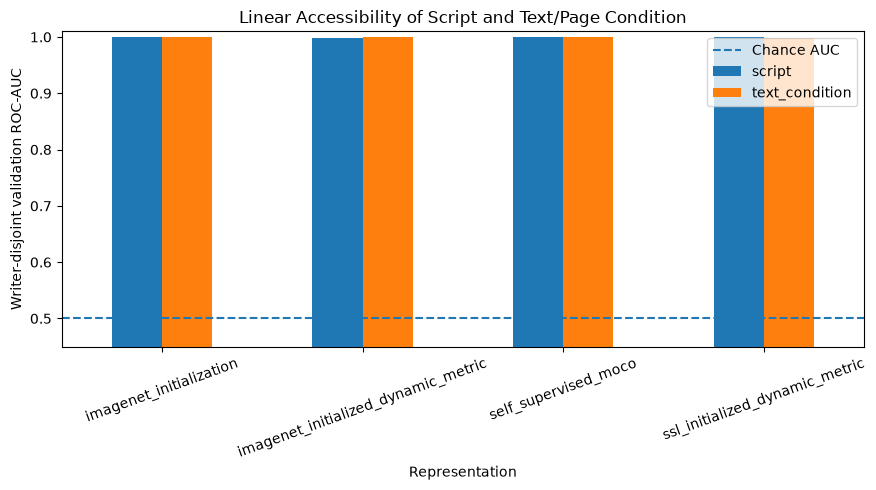

global_linear_probe_results.csv : True
stratified_probe_results.csv : True
leakage_strength_summary.csv : True
page_condition_probe_results.csv : True
permutation_control_results.csv : True
global_nuisance_probe_auc.png : True
leakage_analysis_summary.json : True

Hybrid script global AUC: 0.9999
Hybrid minimum stratified script AUC: 0.9821
Hybrid text-condition global AUC: 0.9984
Hybrid minimum stratified text-condition AUC: 0.9952
Hybrid four-class page-condition accuracy: 0.9821
Mean shuffled-label AUC: 0.503
Minimum observed real probe AUC: 0.9984


In [13]:
GLOBAL_PROBE_PATH = (
    REPORT_DIR
    / "global_linear_probe_results.csv"
)

STRATIFIED_PROBE_PATH = (
    REPORT_DIR
    / "stratified_probe_results.csv"
)

LEAKAGE_STRENGTH_PATH = (
    REPORT_DIR
    / "leakage_strength_summary.csv"
)

PAGE_CONDITION_PATH = (
    REPORT_DIR
    / "page_condition_probe_results.csv"
)

PERMUTATION_PATH = (
    REPORT_DIR
    / "permutation_control_results.csv"
)

FIGURE_PATH = (
    REPORT_DIR
    / "global_nuisance_probe_auc.png"
)

SUMMARY_PATH = (
    REPORT_DIR
    / "leakage_analysis_summary.json"
)

leakage_probe_summary_df.to_csv(
    GLOBAL_PROBE_PATH,
    index=False,
)

stratified_probe_df.to_csv(
    STRATIFIED_PROBE_PATH,
    index=False,
)

leakage_strength_df.to_csv(
    LEAKAGE_STRENGTH_PATH,
    index=False,
)

page_condition_probe_df.to_csv(
    PAGE_CONDITION_PATH,
    index=False,
)

permutation_control_df.to_csv(
    PERMUTATION_PATH,
    index=False,
)

plot_df = (
    leakage_probe_summary_df[
        [
            "representation",
            "target",
            "validation_roc_auc",
        ]
    ]
    .pivot(
        index="representation",
        columns="target",
        values="validation_roc_auc",
    )
)

ax = plot_df.plot(
    kind="bar",
    figsize=(
        9,
        5,
    ),
)

ax.axhline(
    0.5,
    linestyle="--",
    label="Chance AUC",
)

ax.set_ylim(
    0.45,
    1.01,
)

ax.set_xlabel(
    "Representation"
)

ax.set_ylabel(
    "Writer-disjoint validation ROC-AUC"
)

ax.set_title(
    "Linear Accessibility of Script and Text/Page Condition"
)

ax.tick_params(
    axis="x",
    rotation=20,
)

ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

hybrid_script_row = (
    leakage_strength_df[
        (
            leakage_strength_df[
                "representation"
            ]
            == "ssl_initialized_dynamic_metric"
        )
        & (
            leakage_strength_df[
                "target"
            ]
            == "script"
        )
    ]
    .iloc[0]
)

hybrid_text_row = (
    leakage_strength_df[
        (
            leakage_strength_df[
                "representation"
            ]
            == "ssl_initialized_dynamic_metric"
        )
        & (
            leakage_strength_df[
                "target"
            ]
            == "text_condition"
        )
    ]
    .iloc[0]
)

hybrid_page_row = (
    page_condition_probe_df[
        page_condition_probe_df[
            "representation"
        ]
        == "ssl_initialized_dynamic_metric"
    ]
    .iloc[0]
)

summary = {
    "probe_protocol": {
        "probe": "linear_logistic_regression",
        "embedding_dimension": 512,
        "development_writers": 226,
        "validation_writers": 56,
        "writer_disjoint": True,
        "representations_compared": 4,
        "analysis_device": "cpu",
    },
    "hybrid_representation": {
        "script_global_auc": float(
            hybrid_script_row[
                "global_validation_roc_auc"
            ]
        ),
        "script_minimum_stratified_auc": float(
            hybrid_script_row[
                "minimum_validation_roc_auc"
            ]
        ),
        "text_condition_global_auc": float(
            hybrid_text_row[
                "global_validation_roc_auc"
            ]
        ),
        "text_condition_minimum_stratified_auc": float(
            hybrid_text_row[
                "minimum_validation_roc_auc"
            ]
        ),
        "page_condition_accuracy": float(
            hybrid_page_row[
                "validation_accuracy"
            ]
        ),
        "page_condition_macro_auc": float(
            hybrid_page_row[
                "validation_macro_roc_auc"
            ]
        ),
    },
    "controls": {
        "permutation_repeats": PERMUTATION_REPEATS,
        "mean_permuted_auc": float(
            permutation_control_df[
                "permuted_mean_auc"
            ].mean()
        ),
        "maximum_permuted_mean_auc": float(
            permutation_control_df[
                "permuted_mean_auc"
            ].max()
        ),
        "minimum_real_probe_auc": float(
            permutation_control_df[
                "observed_auc"
            ].min()
        ),
    },
    "interpretation": {
        "script_invariance_supported": False,
        "weak_text_condition_accessibility_supported": False,
        "semantic_content_leakage_claim_supported": False,
        "writer_disjoint_nuisance_accessibility_supported": True,
        "next_stage": (
            "controlled_script_invariant_metric_learning"
        ),
    },
}

with SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        indent=2,
    )

saved_paths = [
    GLOBAL_PROBE_PATH,
    STRATIFIED_PROBE_PATH,
    LEAKAGE_STRENGTH_PATH,
    PAGE_CONDITION_PATH,
    PERMUTATION_PATH,
    FIGURE_PATH,
    SUMMARY_PATH,
]

for path in saved_paths:
    print(
        path.name,
        ":",
        path.exists(),
    )

print()

print(
    "Hybrid script global AUC:",
    round(
        hybrid_script_row[
            "global_validation_roc_auc"
        ],
        4,
    ),
)

print(
    "Hybrid minimum stratified script AUC:",
    round(
        hybrid_script_row[
            "minimum_validation_roc_auc"
        ],
        4,
    ),
)

print(
    "Hybrid text-condition global AUC:",
    round(
        hybrid_text_row[
            "global_validation_roc_auc"
        ],
        4,
    ),
)

print(
    "Hybrid minimum stratified text-condition AUC:",
    round(
        hybrid_text_row[
            "minimum_validation_roc_auc"
        ],
        4,
    ),
)

print(
    "Hybrid four-class page-condition accuracy:",
    round(
        hybrid_page_row[
            "validation_accuracy"
        ],
        4,
    ),
)

print(
    "Mean shuffled-label AUC:",
    round(
        permutation_control_df[
            "permuted_mean_auc"
        ].mean(),
        4,
    ),
)

print(
    "Minimum observed real probe AUC:",
    round(
        permutation_control_df[
            "observed_auc"
        ].min(),
        4,
    ),
)

assert all(
    path.exists()
    for path in saved_paths
)

## Script and text/page-condition leakage conclusion

This experiment directly evaluated whether nuisance information remains linearly accessible in frozen writer representations.

Linear probes were trained on the 226 development-training writers and evaluated on 56 completely writer-disjoint validation writers.

Four representations were examined:

- ImageNet initialization
- self-supervised MoCo
- ImageNet-initialized dynamic metric learning
- SSL-initialized dynamic metric learning

### Script accessibility

Script identity was almost perfectly recoverable from every representation.

Validation script ROC-AUC values were:

- ImageNet initialization: 0.9991
- Self-supervised MoCo: 1.0000
- ImageNet-initialized dynamic metric: 0.9986
- SSL-initialized dynamic metric: 0.9999

The best writer-verification representation therefore remains highly script-discriminative.

The finding also shows that the smaller within-versus-cross-script verification gap previously observed for standalone SSL cannot be interpreted as evidence of script invariance.

### Stratified script probes

Script remained highly predictable even after controlling for the text/page condition.

The minimum stratified script ROC-AUC across the four representations ranged from 0.9821 to 1.0000.

For the SSL-initialized metric representation, the minimum stratified script ROC-AUC was 0.9821.

Therefore, near-perfect script accessibility is not explained solely by the global association between script and page condition.

### Text/page-condition accessibility

The fixed-versus-variable text/page condition was also almost perfectly recoverable.

Global validation ROC-AUC ranged from 0.9984 to 0.9998.

The signal remained strong when probes were trained and evaluated separately inside Arabic and English subsets.

For the SSL-initialized metric representation:

- global text-condition ROC-AUC: 0.9984
- minimum within-script stratified ROC-AUC: 0.9952

This provides strong evidence that page/text-condition information remains explicitly accessible in the writer embedding.

However, this result should not be described as pure semantic-content leakage.

In QUWI, the `same_text` label is tied to specific page conditions and may also capture layout, structural, or acquisition-related regularities.

The appropriate interpretation is therefore text/page-condition accessibility.

### Joint page-condition accessibility

A four-class probe was also used to predict the original QUWI page condition:

1. Arabic variable text
2. Arabic same text
3. English variable text
4. English same text

Chance accuracy is 25%.

Validation accuracy was:

- ImageNet initialization: 96.88%
- Self-supervised MoCo: 98.66%
- ImageNet-initialized dynamic metric: 96.43%
- SSL-initialized dynamic metric: 98.21%

The hybrid representation achieved a macro ROC-AUC of 0.9984.

This confirms that the embedding space contains highly accessible information about the combined script and page condition.

### Permutation control

As a pipeline sanity check, development probe labels were randomly permuted while the embeddings and validation labels were left unchanged.

Across the script and text-condition controls:

- mean shuffled-label ROC-AUC was approximately 0.503
- the largest mean shuffled-control ROC-AUC was approximately 0.532
- the weakest observed real probe ROC-AUC was 0.9984

The shuffled controls therefore behaved close to chance while the real probes remained near perfect.

The 20-repeat empirical values are treated only as a sanity control and not as final inferential p-values.

### Main finding

Writer verification performance improved substantially across the preceding experiments, but nuisance accessibility remained extremely high.

The current best writer representation is therefore writer-discriminative but not script-invariant and not page-condition-invariant.

This establishes an empirical motivation for the next research stage.

### Next controlled experiment

The next model should explicitly suppress script information while preserving writer discrimination.

The first invariant-learning experiment should target script only rather than simultaneously suppressing both script and page condition.

This keeps the experiment interpretable and allows the effect of script suppression to be isolated.

A suitable controlled design is:

- retain the SSL-initialized dynamic writer metric objective
- attach a script-prediction adversary to the 512-dimensional embedding
- use gradient reversal so the encoder is optimized to make script prediction difficult
- retain writer-verification validation ROC-AUC as the main utility metric
- measure script-probe ROC-AUC after training as the leakage metric
- evaluate the trade-off between writer discrimination, cross-script performance, and script accessibility

Only after isolating the script effect should additional page-condition suppression be introduced.

The official-test split should remain descriptive and must not be used to tune the adversarial strength or choose the invariant model.